# Building a Stylized Chatbot: A Beginner-Friendly NLP Notebook

This notebook walks step by step through the basic ideas behind NLP while we build a small **stylized chatbot**.

We will:
- choose an **open-source text** to imitate
- clean and tokenize the text
- explore **stop words**, **Zipf's law**, **POS tagging**, **n-grams**, and **skip-grams**
- build a simple **probabilistic next-token generator**
- turn it into a **stylized chatbot**
- lightly touch **embeddings**
- lightly touch **modern transformers**
- finish with a tiny **machine translation** section:
  - style translation (modern English -> literary style)
  - a simple **Latin translator** and a tiny **Latin chatbot**

> This is a teaching notebook. Our chatbot is intentionally small and interpretable, not state of the art.


## How to use this notebook

1. Run the import/setup cell.
2. Pick a corpus by changing `CORPUS_CHOICE`.
3. Run the notebook from top to bottom.
4. Try your own prompts in the chatbot and translation sections.

The notebook is designed to be beginner-friendly:
- the code uses clear helper functions
- plots render directly in the notebook
- every major section explains what is happening and why


In [1]:
# If you are missing packages, uncomment the next line and run it once.
!pip install numpy pandas matplotlib scikit-learn nltk

In [2]:


%matplotlib inline

import math
import random
import re
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# NLTK is helpful here, but this notebook is written with fallbacks so it can still run
# even if you do not have NLTK data packages downloaded.
try:
    import nltk
    from nltk.tag import RegexpTagger
    from nltk.util import skipgrams
    HAS_NLTK = True
except Exception:
    HAS_NLTK = False

    def skipgrams(sequence, n, k):
        # Small fallback version that only supports 2-word skip-grams.
        if n != 2:
            raise ValueError("Fallback skipgram function only supports n=2.")
        items = list(sequence)
        for i in range(len(items)):
            for j in range(i + 1, min(len(items), i + k + 2)):
                yield (items[i], items[j])

    class RegexpTagger:
        def __init__(self, patterns):
            self.patterns = [(re.compile(pattern), tag) for pattern, tag in patterns]

        def tag(self, tokens):
            tagged = []
            for token in tokens:
                chosen_tag = "NN"
                for pattern, tag in self.patterns:
                    if pattern.fullmatch(token):
                        chosen_tag = tag
                        break
                tagged.append((token, chosen_tag))
            return tagged

random.seed(42)
np.random.seed(42)
STOP_WORDS = set(ENGLISH_STOP_WORDS)

print("Setup complete.")
print("NLTK installed:", HAS_NLTK)


Setup complete.
NLTK installed: True


## 1. Pick a style corpus

A language model learns patterns from text. If we train on Jane Austen, the model will sound different from Shakespeare or the King James Bible.

This notebook uses public-domain texts stored in a local `data/` folder so it can work offline once you have the notebook bundle.

Try one of these:
- `austen`
- `shakespeare`
- `bible`


In [3]:
CORPUS_CHOICE = "bible"   # try: "austen", "shakespeare", or "bible"

CORPUS_FILES = {
    "austen": "pride_and_prejudice.txt",
    "shakespeare": "hamlet.txt",
    "bible": "bible_kjv.txt",
}


def locate_data_file(filename: str) -> Path:
    # Look for a data file in a few common locations.
    candidates = [
        Path("data") / filename,
        Path.cwd() / "data" / filename,
        Path("/mnt/data/data") / filename,
        Path("/mnt/data") / "data" / filename,
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Make sure the notebook and data folder stay together."
    )

print("Selected corpus:", CORPUS_CHOICE)
print("Expected file:", CORPUS_FILES[CORPUS_CHOICE])


Selected corpus: bible
Expected file: bible_kjv.txt


## 2. Helper functions

These helper functions keep the later code simple. They handle:
- cleaning the raw text
- sentence splitting
- word tokenization
- stop-word filtering
- simple POS tagging
- building n-gram models
- generating text


https://regex101.com/

In [16]:
def clean_gutenberg_text(text: str) -> str:
    # Remove a little boilerplate and normalize whitespace.
    text = re.sub(r"\*\*\* START OF THE PROJECT GUTENBERG EBOOK.*?\*\*\*", " ", text, flags=re.S)
    text = re.sub(r"\*\*\* END OF THE PROJECT GUTENBERG EBOOK.*", " ", text, flags=re.S)
    text = re.sub(r"\d+:\d+", " ", text)
    text = re.sub(r"[_\[\]():]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def sentence_tokenize(text: str):
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if s.strip()]


TOKEN_PATTERN = r"[A-Za-z]+(?:'[A-Za-z]+)?|[.,!?;:]"


def word_tokenize(text: str, lowercase: bool = True):
    if lowercase:
        text = text.lower()
    return re.findall(TOKEN_PATTERN, text)


# A lightweight rule-based POS tagger fallback.
regex_patterns = [
    (r"^(the|a|an)$", "DT"),
    (r"^(and|or|but|if|while|because|though|although)$", "CC"),
    (r"^(i|you|he|she|it|we|they|me|him|her|us|them)$", "PRP"),
    (r"^(my|your|his|her|our|their)$", "PRP$"),
    (r"^(is|am|are|was|were|be|being|been)$", "VB"),
    (r"^(have|has|had|do|does|did|shall|will|may|might|can|could|should|would|must)$", "MD"),
    (r".*ing$", "VBG"),
    (r".*ed$", "VBD"),
    (r".*ly$", "RB"),
    (r".*(ous|ful|able|ible|al|ive|ic)$", "JJ"),
    (r".*ness$", "NN"),
    (r".*ment$", "NN"),
    (r".*tion$", "NN"),
    (r".*s$", "NNS"),
    (r"^[0-9]+$", "CD"),
    (r"^[.,!?;:]$", "."),
    (r".*", "NN"),
]

regex_tagger = RegexpTagger(regex_patterns)


def tag_tokens(tokens):
    # Try NLTK's POS tagger first. If data is unavailable, use the regex tagger.
    try:
        import nltk
        try:
            return nltk.pos_tag(tokens)
        except LookupError:
            return regex_tagger.tag(tokens)
    except Exception:
        return regex_tagger.tag(tokens)


def load_corpus(choice: str = "austen"):
    filename = CORPUS_FILES[choice]
    path = locate_data_file(filename)
    raw_text = path.read_text(encoding="utf-8", errors="ignore")
    text = clean_gutenberg_text(raw_text)
    sentences = sentence_tokenize(text)
    tokens = word_tokenize(text)
    alpha_tokens = [t for t in tokens if re.fullmatch(r"[a-z]+(?:'[a-z]+)?", t)]
    content_tokens = [t for t in alpha_tokens if t not in STOP_WORDS]
    return {
        "choice": choice,
        "path": path,
        "raw_text": raw_text,
        "text": text,
        "sentences": sentences,
        "tokens": tokens,
        "alpha_tokens": alpha_tokens,
        "content_tokens": content_tokens,
    }


def detokenize(tokens):
    text = " ".join(tokens)
    text = re.sub(r"\s+([.,!?;:])", r"", text)
    text = text.replace(" n't", "n't")
    return text


def most_common_tokens(tokens, n=15):
    return pd.DataFrame(Counter(tokens).most_common(n), columns=["token", "count"])


def zipf_dataframe(tokens, top_n=200):
    counts = Counter(tokens)
    common = counts.most_common(top_n)
    ranks = np.arange(1, len(common) + 1)
    frequencies = np.array([count for _, count in common])
    words = [word for word, _ in common]
    return pd.DataFrame({"rank": ranks, "frequency": frequencies, "token": words})


def pos_distribution(tokens, sample_size=1500):
    tagged = tag_tokens(tokens[:sample_size])
    counts = Counter(tag for _, tag in tagged)
    return tagged, pd.DataFrame(counts.most_common(), columns=["pos_tag", "count"])


def build_ngram_model(sentences, n=2):
    model = defaultdict(Counter)
    for sentence in sentences:
        sentence_tokens = word_tokenize(sentence)
        if not sentence_tokens:
            continue
        padded = ["<s>"] * (n - 1) + sentence_tokens + ["</s>"]
        for i in range(len(padded) - n + 1):
            context = tuple(padded[i:i + n - 1]) if n > 1 else tuple()
            next_token = padded[i + n - 1]
            model[context][next_token] += 1
    return model


def next_token_distribution(model, context, top_n=10):
    counts = model.get(tuple(context), Counter())
    total = sum(counts.values())
    rows = []
    for token, count in counts.most_common(top_n):
        rows.append({
            "next_token": token,
            "count": count,
            "probability": count / total if total else 0.0,
        })
    return pd.DataFrame(rows)


def sample_from_counter(counter, temperature=1.0, top_k=None):
    items = list(counter.items())
    if not items:
        return None
    if top_k is not None:
        items = items[:top_k]
    tokens, counts = zip(*items)
    probabilities = np.array(counts, dtype=float)
    probabilities = probabilities / probabilities.sum()
    temperature = max(temperature, 1e-3)
    probabilities = probabilities ** (1.0 / temperature)
    probabilities = probabilities / probabilities.sum()
    return np.random.choice(tokens, p=probabilities)


def choose_start_context(model, n):
    start_context = tuple(["<s>"] * (n - 1)) if n > 1 else tuple()
    if start_context in model:
        return list(start_context)
    return list(random.choice(list(model.keys())))


def generate_text(model, n=2, seed_text="", max_tokens=40, temperature=1.0, top_k=None):
    seed_tokens = [token for token in word_tokenize(seed_text) if token not in ".,!?;:"]

    if n == 1:
        generated = []
        context = tuple()
    else:
        context = seed_tokens[-(n - 1):]
        if len(context) < n - 1 or tuple(context) not in model:
            context = choose_start_context(model, n)
        generated = [token for token in context if token != "<s>"]

    for _ in range(max_tokens):
        counter = model.get(tuple(context), None) if n > 1 else model.get(tuple(), None)
        if not counter:
            break
        next_token = sample_from_counter(counter, temperature=temperature, top_k=top_k)
        if next_token is None or next_token == "</s>":
            break
        generated.append(next_token)
        if n > 1:
            context = (context + [next_token])[-(n - 1):]

    return detokenize(generated)


In [17]:
corpus = load_corpus(CORPUS_CHOICE)

print("Loaded corpus from:", corpus["path"])
print("Number of sentences:", len(corpus["sentences"]))
print("Number of alphabetic tokens:", len(corpus["alpha_tokens"]))
print("Number of content tokens (stop words removed):", len(corpus["content_tokens"]))


Loaded corpus from: data/bible_kjv.txt
Number of sentences: 1151
Number of alphabetic tokens: 29838
Number of content tokens (stop words removed): 12909


## 3. Preview the text

Before modeling anything, it is always good to inspect the data.


In [18]:
print(corpus["text"][:1200])

1 1 In the beginning God created the heaven and the earth. 1 2 And the earth was without form, and void; and darkness was upon the face of the deep. And the Spirit of God moved upon the face of the waters. 1 3 And God said, Let there be light and there was light. 1 4 And God saw the light, that it was good and God divided the light from the darkness. 1 5 And God called the light Day, and the darkness he called Night. And the evening and the morning were the first day. 1 6 And God said, Let there be a firmament in the midst of the waters, and let it divide the waters from the waters. 1 7 And God made the firmament, and divided the waters which were under the firmament from the waters which were above the firmament and it was so. 1 8 And God called the firmament Heaven. And the evening and the morning were the second day. 1 9 And God said, Let the waters under the heaven be gathered together unto one place, and let the dry land appear and it was so. 1 10 And God called the dry land Earth

In [19]:
stats_df = pd.DataFrame([
    {
        "corpus": corpus["choice"],
        "sentences": len(corpus["sentences"]),
        "alphabetic_tokens": len(corpus["alpha_tokens"]),
        "content_tokens": len(corpus["content_tokens"]),
        "unique_words": len(set(corpus["alpha_tokens"])),
    }
])
stats_df

,corpus,sentences,alphabetic_tokens,content_tokens,unique_words
0,bible,1151,29838,12909,2127


## 4. Tokenization

Tokenization means breaking text into smaller units.

Two common kinds:
- **sentence tokenization**: split into sentences
- **word tokenization**: split into words or punctuation tokens

This matters because our model does not directly read raw paragraphs. It reads **tokens**.


In [20]:
print("First 5 sentences:")
print()
for sentence in corpus["sentences"][:5]:
    print("-", sentence)

print()
print("First 40 tokens:")
print()
print(corpus["tokens"][:40])

First 5 sentences:

- 1 1 In the beginning God created the heaven and the earth.
- 1 2 And the earth was without form, and void; and darkness was upon the face of the deep.
- And the Spirit of God moved upon the face of the waters.
- 1 3 And God said, Let there be light and there was light.
- 1 4 And God saw the light, that it was good and God divided the light from the darkness.

First 40 tokens:

['in', 'the', 'beginning', 'god', 'created', 'the', 'heaven', 'and', 'the', 'earth', '.', 'and', 'the', 'earth', 'was', 'without', 'form', ',', 'and', 'void', ';', 'and', 'darkness', 'was', 'upon', 'the', 'face', 'of', 'the', 'deep', '.', 'and', 'the', 'spirit', 'of', 'god', 'moved', 'upon', 'the', 'face']


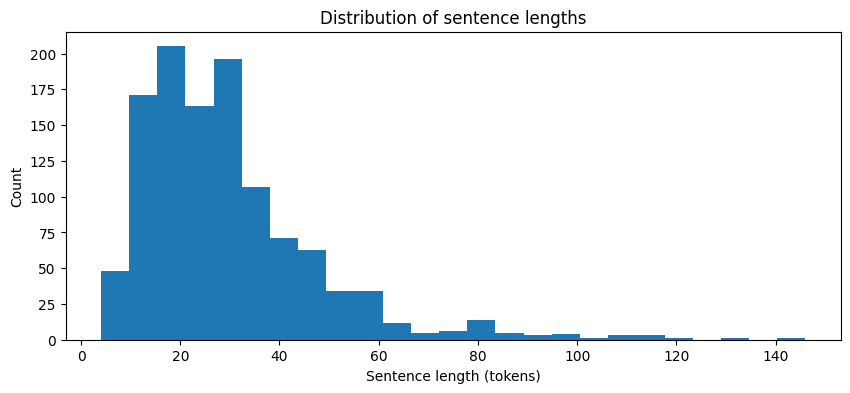

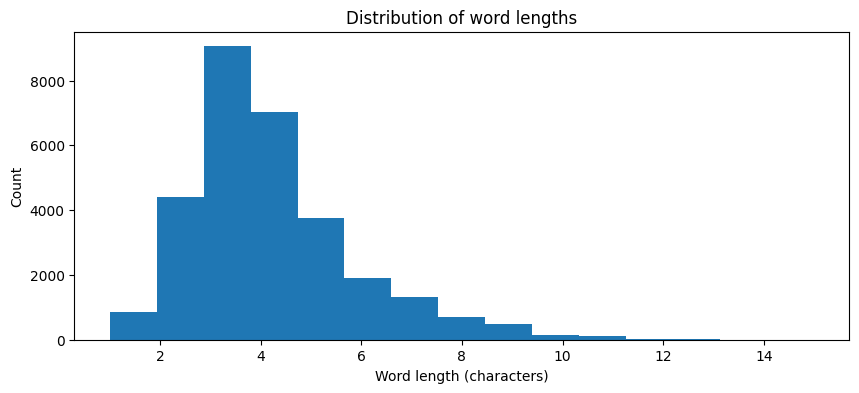

In [21]:
sentence_lengths = [len(word_tokenize(sentence)) for sentence in corpus["sentences"]]
word_lengths = [len(token) for token in corpus["alpha_tokens"]]

plt.figure(figsize=(10, 4))
plt.hist(sentence_lengths, bins=25)
plt.xlabel("Sentence length (tokens)")
plt.ylabel("Count")
plt.title("Distribution of sentence lengths")
plt.show()

plt.figure(figsize=(10, 4))
plt.hist(word_lengths, bins=15)
plt.xlabel("Word length (characters)")
plt.ylabel("Count")
plt.title("Distribution of word lengths")
plt.show()

## 5. Stop words

**Stop words** are extremely common words such as `the`, `and`, `of`, and `to`.

They are often useful for grammar, but they can hide the more distinctive words in a text. Below we compare the most common words **with** and **without** stop words.


Most common tokens (including stop words):


,token,count
0,and,2946
1,the,1968
2,of,1054
3,he,515
4,his,492
5,to,489
6,in,442
7,unto,428
8,that,425
9,i,396


Most common content tokens (stop words removed):


,token,count
0,unto,428
1,said,378
2,thou,249
3,thee,226
4,thy,218
5,god,193
6,lord,188
7,s,187
8,shall,173
9,son,149


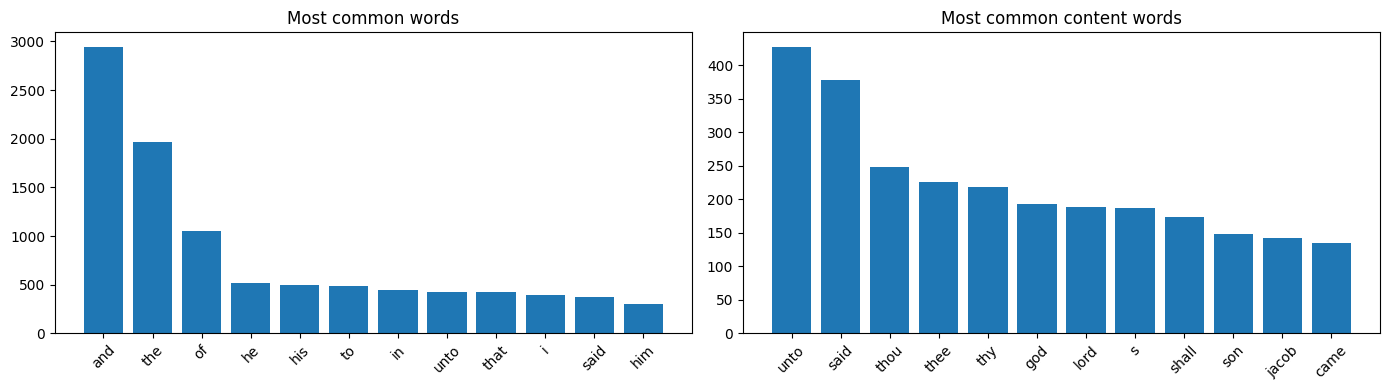

In [22]:
top_all = most_common_tokens(corpus["alpha_tokens"], n=12)
top_content = most_common_tokens(corpus["content_tokens"], n=12)

print("Most common tokens (including stop words):")
display(top_all)

print("Most common content tokens (stop words removed):")
display(top_content)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(top_all["token"], top_all["count"])
axes[0].set_title("Most common words")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(top_content["token"], top_content["count"])
axes[1].set_title("Most common content words")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

## 6. Zipf's law

Zipf's law is one of the most famous empirical patterns in language.

It says that:
- the most common word is extremely frequent
- the second most common word is much less frequent
- frequency tends to drop roughly like a power law as rank increases

A log-log plot often looks close to a straight line.


In [23]:
zipf_df = zipf_dataframe(corpus["alpha_tokens"], top_n=200)
zipf_df.head(10)

,rank,frequency,token
0,1,2946,and
1,2,1968,the
2,3,1054,of
3,4,515,he
4,5,492,his
5,6,489,to
6,7,442,in
7,8,428,unto
8,9,425,that
9,10,396,i


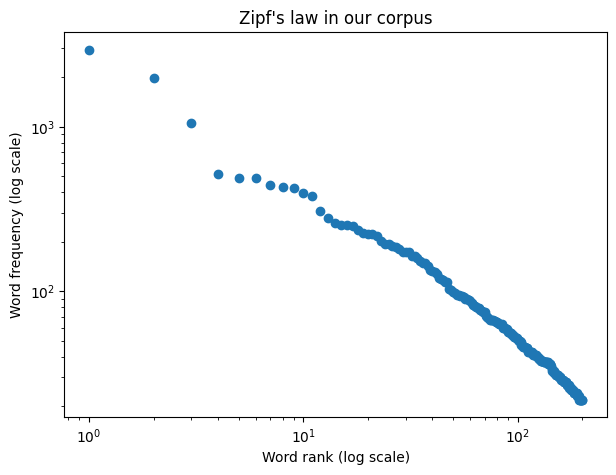

In [24]:
plt.figure(figsize=(7, 5))
plt.loglog(zipf_df["rank"], zipf_df["frequency"], marker="o", linestyle="none")
plt.xlabel("Word rank (log scale)")
plt.ylabel("Word frequency (log scale)")
plt.title("Zipf's law in our corpus")
plt.show()

## 7. Part-of-speech tagging

A **part of speech (POS)** tag describes a token's grammatical role.

Examples:
- `NN` = noun
- `VB` = verb
- `JJ` = adjective
- `RB` = adverb

This notebook uses a full NLTK tagger if available; otherwise it falls back to a simple rule-based tagger so the notebook still runs.


In [25]:
tagged_tokens, pos_df = pos_distribution(corpus["alpha_tokens"], sample_size=1500)

print("Sample tagged tokens:")
print(tagged_tokens[:30])

pos_df.head(12)

Sample tagged tokens:
[('in', 'NN'), ('the', 'DT'), ('beginning', 'VBG'), ('god', 'NN'), ('created', 'VBD'), ('the', 'DT'), ('heaven', 'NN'), ('and', 'CC'), ('the', 'DT'), ('earth', 'NN'), ('and', 'CC'), ('the', 'DT'), ('earth', 'NN'), ('was', 'VB'), ('without', 'NN'), ('form', 'NN'), ('and', 'CC'), ('void', 'NN'), ('and', 'CC'), ('darkness', 'NN'), ('was', 'VB'), ('upon', 'NN'), ('the', 'DT'), ('face', 'NN'), ('of', 'NN'), ('the', 'DT'), ('deep', 'NN'), ('and', 'CC'), ('the', 'DT'), ('spirit', 'NN')]


,pos_tag,count
0,NN,806
1,DT,208
2,CC,162
3,PRP,75
4,VB,67
5,VBD,46
6,VBG,39
7,NNS,38
8,PRP$,24
9,MD,23


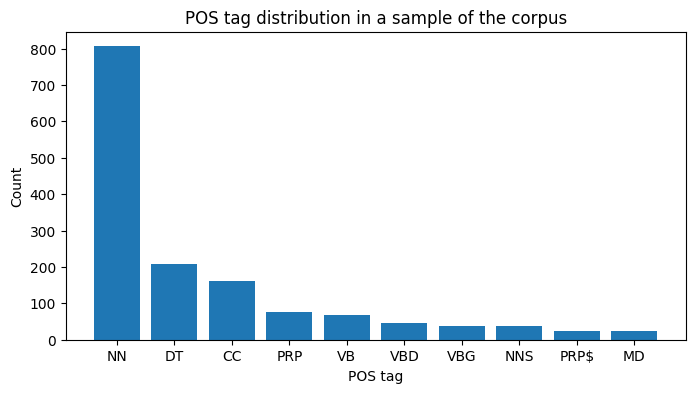

In [26]:
top_pos = pos_df.head(10)

plt.figure(figsize=(8, 4))
plt.bar(top_pos["pos_tag"], top_pos["count"])
plt.xlabel("POS tag")
plt.ylabel("Count")
plt.title("POS tag distribution in a sample of the corpus")
plt.show()

## 8. Bigrams, trigrams, and skip-grams

An **n-gram** is a short sequence of tokens.
- unigram: one token
- bigram: two tokens
- trigram: three tokens

A **skip-gram** allows us to skip over a small number of words, which can reveal looser patterns.


In [27]:
bigrams = Counter(zip(corpus["content_tokens"], corpus["content_tokens"][1:]))
trigrams = Counter(zip(corpus["content_tokens"], corpus["content_tokens"][1:], corpus["content_tokens"][2:]))
skip_bigrams = Counter(skipgrams(corpus["content_tokens"][:2500], 2, 2))

bigram_df = pd.DataFrame(
    [(" ".join(pair), count) for pair, count in bigrams.most_common(10)],
    columns=["bigram", "count"],
)
trigram_df = pd.DataFrame(
    [(" ".join(triple), count) for triple, count in trigrams.most_common(10)],
    columns=["trigram", "count"],
)
skipgram_df = pd.DataFrame(
    [(" ~ ".join(pair), count) for pair, count in skip_bigrams.most_common(10)],
    columns=["skipgram", "count"],
)

print("Top bigrams:")
display(bigram_df)

print("Top trigrams:")
display(trigram_df)

print("Top skip-grams (with skip distance up to 2):")
display(skipgram_df)

Top bigrams:


,bigram,count
0,said unto,129
1,came pass,56
2,thou shalt,45
3,thou hast,37
4,years begat,34
5,thy seed,33
6,lord god,31
7,pray thee,30
8,god said,29
9,unto thee,23


Top trigrams:


,trigram,count
0,years begat sons,17
1,begat sons daughters,17
2,god said unto,14
3,lord said unto,12
4,father s house,11
5,said unto abraham,10
6,thee thou shalt,9
7,thirty years begat,9
8,sons daughters days,9
9,god said let,8


Top skip-grams (with skip distance up to 2):


,skipgram,count
0,god ~ said,22
1,lord ~ god,21
2,years ~ begat,19
3,said ~ unto,16
4,shalt ~ thou,16
5,lived ~ begat,15
6,earth ~ god,14
7,thou ~ shalt,14
8,lived ~ years,14
9,lord ~ said,13


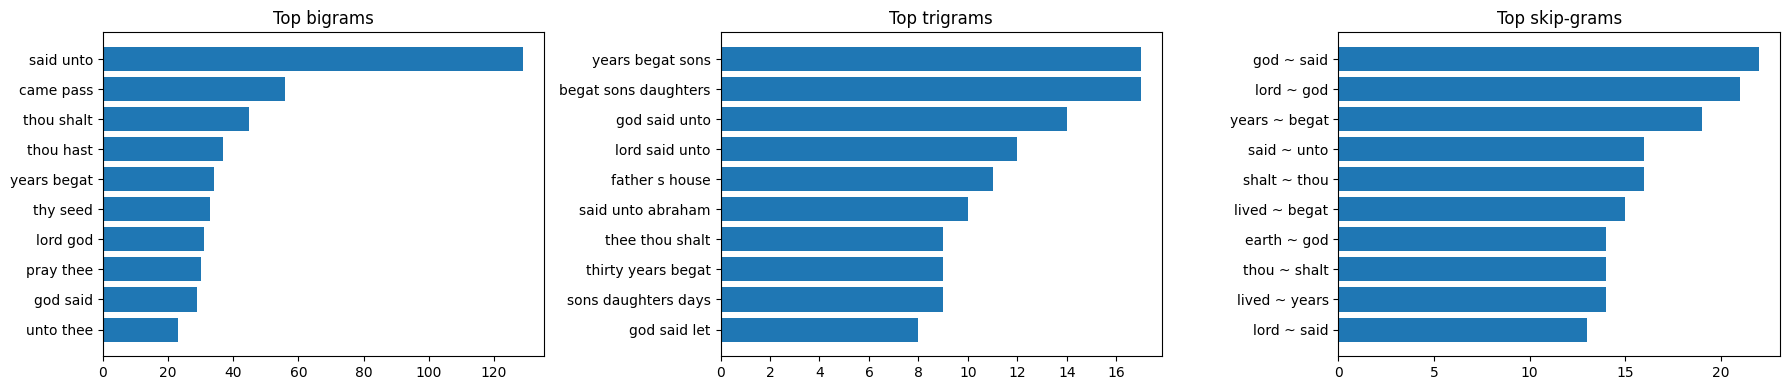

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].barh(bigram_df["bigram"], bigram_df["count"])
axes[0].set_title("Top bigrams")
axes[0].invert_yaxis()

axes[1].barh(trigram_df["trigram"], trigram_df["count"])
axes[1].set_title("Top trigrams")
axes[1].invert_yaxis()

axes[2].barh(skipgram_df["skipgram"], skipgram_df["count"])
axes[2].set_title("Top skip-grams")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Probabilistic next-token prediction

This is the central idea behind language generation.

We estimate probabilities such as:
- **bigram model**: `P(next_word | current_word)`
- **trigram model**: `P(next_word | previous_two_words)`

Then we sample from that probability distribution.


In [29]:
unigram_model = build_ngram_model(corpus["sentences"], n=1)
bigram_model = build_ngram_model(corpus["sentences"], n=2)
trigram_model = build_ngram_model(corpus["sentences"], n=3)

print("Models built.")
print("Number of unigram contexts:", len(unigram_model))
print("Number of bigram contexts:", len(bigram_model))
print("Number of trigram contexts:", len(trigram_model))

Models built.
Number of unigram contexts: 1
Number of bigram contexts: 2133
Number of trigram contexts: 12187


In [43]:
seed_word = "he"
next_df = next_token_distribution(bigram_model, context=(seed_word,), top_n=10)
print(f"Most likely next tokens after '{seed_word}':")
next_df

Most likely next tokens after 'he':


,next_token,count,probability
0,said,97,0.188350
1,had,45,0.087379
2,was,22,0.042718
3,begat,18,0.034951
4,called,14,0.027184
5,took,14,0.027184
6,hath,12,0.023301
7,is,11,0.021359
8,died,10,0.019417
9,came,9,0.017476


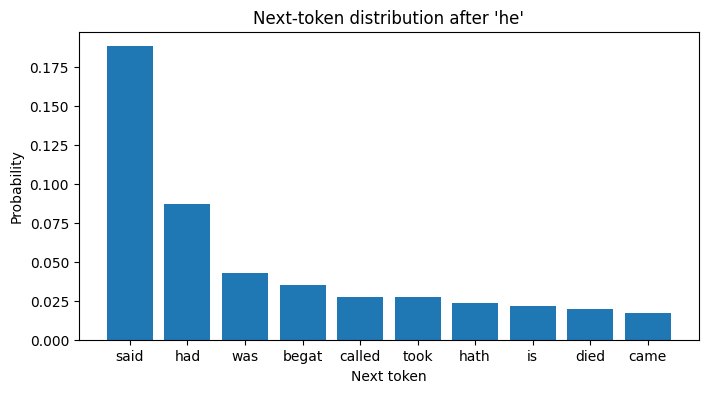

In [44]:
if not next_df.empty:
    plt.figure(figsize=(8, 4))
    plt.bar(next_df["next_token"], next_df["probability"])
    plt.xlabel("Next token")
    plt.ylabel("Probability")
    plt.title(f"Next-token distribution after '{seed_word}'")
    plt.show()
else:
    print("That seed word was not found in the model. Try another word.")

### Compare unigram, bigram, and trigram generation

We use the same starting idea and see what each model produces.


In [55]:
seed_text = "he"

sample_outputs = pd.DataFrame([
    {"model": "unigram", "output": generate_text(unigram_model, n=1, seed_text=seed_text, max_tokens=20, temperature=1.0)},
    {"model": "bigram", "output": generate_text(bigram_model, n=2, seed_text=seed_text, max_tokens=20, temperature=0.9, top_k=8)},
    {"model": "trigram", "output": generate_text(trigram_model, n=3, seed_text=seed_text, max_tokens=20, temperature=0.9, top_k=8)},
])
sample_outputs

,model,output
0,unigram,old of multiply and son heaven garments sent
1,bigram,he called his wife s sake and the waters whic...
2,trigram,and the morning and the earth


Usually you will notice:
- the **unigram** model ignores local grammar and sounds random
- the **bigram** model is better because it sees one step of context
- the **trigram** model is usually more coherent because it sees two steps of context

That is why next-token prediction is such a useful bridge from statistics to text generation.


In [56]:
# Pick a seed and model, then show likely next tokens and sample one at random.
seed_text = "i am"
model = trigram_model
n = 3
min_probability = 0.0001
display_n = 10

seed_tokens = [t for t in word_tokenize(seed_text) if t not in ".,!?;:"]
context = tuple(seed_tokens[-(n - 1):]) if n > 1 else tuple()

if n > 1 and (len(context) < n - 1 or context not in model):
    context = tuple(choose_start_context(model, n))

counter = model.get(context, Counter())
total = sum(counter.values())

if total == 0:
    print("No next-token candidates found for context:", context)
else:
    next_tokens_df = pd.DataFrame(
        [
            {
                "next_token": token,
                "count": count,
                "probability": count / total,
            }
            for token, count in counter.most_common()
            if count / total > min_probability
        ]
    )

    print("Context:", context)
    print(f"Candidates with p > {min_probability}: {len(next_tokens_df)}")
    display(next_tokens_df.head(display_n))

    sampled_next_token = np.random.choice(
        next_tokens_df["next_token"],
        p=next_tokens_df["probability"] / next_tokens_df["probability"].sum(),
    )

    print("Randomly selected next token:", sampled_next_token)
    print("Updated text:", detokenize(seed_tokens + [sampled_next_token]))

Context: ('i', 'am')
Candidates with p > 0.0001: 15


,next_token,count,probability
0,the,6,0.250000
1,thy,2,0.083333
2,.,2,0.083333
3,a,2,0.083333
4,with,2,0.083333
5,waxed,1,0.041667
6,abraham,1,0.041667
7,faint,1,0.041667
8,at,1,0.041667
9,old,1,0.041667


Randomly selected next token: abraham
Updated text: i am abraham


Show in terminal


## 10. Turning generation into a stylized chatbot

Our chatbot will be simple:
1. take a user prompt
2. retrieve a somewhat related sentence from the corpus using TF-IDF similarity
3. choose a seed from the prompt or retrieved sentence
4. continue in the style of the corpus using a trigram model

This is not a modern chat model, but it is a very nice teaching example.


In [57]:
class StylizedChatbot:
    def __init__(self, corpus):
        self.corpus = corpus
        self.sentences = [s for s in corpus["sentences"] if len(word_tokenize(s)) >= 5]
        self.vectorizer = TfidfVectorizer(stop_words="english", max_features=3000)
        self.matrix = self.vectorizer.fit_transform(self.sentences)
        self.bigram_model = build_ngram_model(self.sentences, n=2)
        self.trigram_model = build_ngram_model(self.sentences, n=3)
        self.vocab = set(corpus["alpha_tokens"])

    def retrieve_sentence(self, query):
        query_vector = self.vectorizer.transform([query])
        similarities = cosine_similarity(query_vector, self.matrix)[0]
        best_index = int(np.argmax(similarities))
        return self.sentences[best_index], float(similarities[best_index])

    def choose_seed(self, query, retrieved_sentence):
        query_tokens = [t for t in word_tokenize(query) if t.isalpha() and t not in STOP_WORDS]
        matched = [t for t in query_tokens if t in self.vocab]
        if len(matched) >= 2:
            return " ".join(matched[-2:])
        if len(matched) == 1:
            return matched[0]
        retrieved_tokens = [t for t in word_tokenize(retrieved_sentence) if t.isalpha()]
        return " ".join(retrieved_tokens[-2:])

    def reply(self, query, temperature=0.8, max_tokens=30):
        retrieved_sentence, similarity = self.retrieve_sentence(query)
        seed = self.choose_seed(query, retrieved_sentence)
        continuation = generate_text(
            self.trigram_model,
            n=3,
            seed_text=seed,
            max_tokens=max_tokens,
            temperature=temperature,
            top_k=8,
        )
        if not continuation:
            continuation = generate_text(
                self.bigram_model,
                n=2,
                seed_text=seed,
                max_tokens=max_tokens,
                temperature=temperature,
                top_k=8,
            )

        response = retrieved_sentence
        if continuation and continuation.lower() not in retrieved_sentence.lower():
            response = f"{retrieved_sentence} {continuation}"

        return {
            "query": query,
            "retrieved_sentence": retrieved_sentence,
            "similarity": similarity,
            "seed": seed,
            "response": response,
        }


chatbot = StylizedChatbot(corpus)
print("Stylized chatbot ready.")

Stylized chatbot ready.


In [59]:
demo_prompts = [
    "Who created the universe?",
]

for prompt in demo_prompts:
    result = chatbot.reply(prompt, temperature=0.85, max_tokens=24)
    print("USER:", prompt)
    print("BOT :", result["response"])
    print("seed used:", result["seed"], "| similarity:", round(result["similarity"], 3))
    print("-" * 90)

USER: Who created the universe?
BOT : In the day that God created man, in the likeness of God made he him; 5 2 Male and female created he them; and blessed them, and called their name Adam, in the day when they were created. and the earth and the earth and the evening and the earth and to every beast of the field and
seed used: created | similarity: 0.728
------------------------------------------------------------------------------------------


In [65]:
# Try your own prompt here.
user_prompt = "Give me advice about patience and hope."
result = chatbot.reply(user_prompt, temperature=0.8, max_tokens=25)

print("USER:", user_prompt)
print("BOT :", result["response"])
print("Retrieved sentence:", result["retrieved_sentence"])
print("Seed used:", result["seed"])
print("Similarity score:", round(result["similarity"], 3))

USER: Give me advice about patience and hope.
BOT : 1 1 In the beginning God created the heaven and the earth. the earth and to thy brother s keeper
Retrieved sentence: 1 1 In the beginning God created the heaven and the earth.
Seed used: the earth
Similarity score: 0.0


## 11. A light introduction to embeddings

A classic idea in NLP is that words can be represented as vectors.

Very loosely:
- words that appear in similar contexts get similar vectors
- those vectors can capture rough semantic relationships

To keep everything transparent, we will build a tiny **co-occurrence-based embedding**:
1. count which words appear near other words
2. build a co-occurrence matrix
3. reduce it to 2 dimensions with SVD
4. plot the points


In [66]:
def build_cooccurrence_embeddings(tokens, vocab_size=80, window=2):
    freq = Counter(token for token in tokens if token.isalpha() and token not in STOP_WORDS)
    vocab = [word for word, _ in freq.most_common(vocab_size)]
    index = {word: i for i, word in enumerate(vocab)}

    matrix = np.zeros((len(vocab), len(vocab)), dtype=float)
    for i, token in enumerate(tokens):
        if token not in index:
            continue
        left = max(0, i - window)
        right = min(len(tokens), i + window + 1)
        for j in range(left, right):
            if i == j:
                continue
            other = tokens[j]
            if other in index:
                matrix[index[token], index[other]] += 1.0

    reducer = TruncatedSVD(n_components=2, random_state=42)
    coords = reducer.fit_transform(matrix)
    return vocab, matrix, coords


vocab, cooc_matrix, coords = build_cooccurrence_embeddings(corpus["alpha_tokens"][:6000], vocab_size=60, window=2)
embedding_df = pd.DataFrame({
    "word": vocab,
    "x": coords[:, 0],
    "y": coords[:, 1],
})
embedding_df.head()

,word,x,y
0,earth,4.368887,3.388398
1,god,26.874785,-21.850343
2,unto,18.405908,-2.684047
3,thou,3.965635,-1.416317
4,shall,3.916239,-0.080727


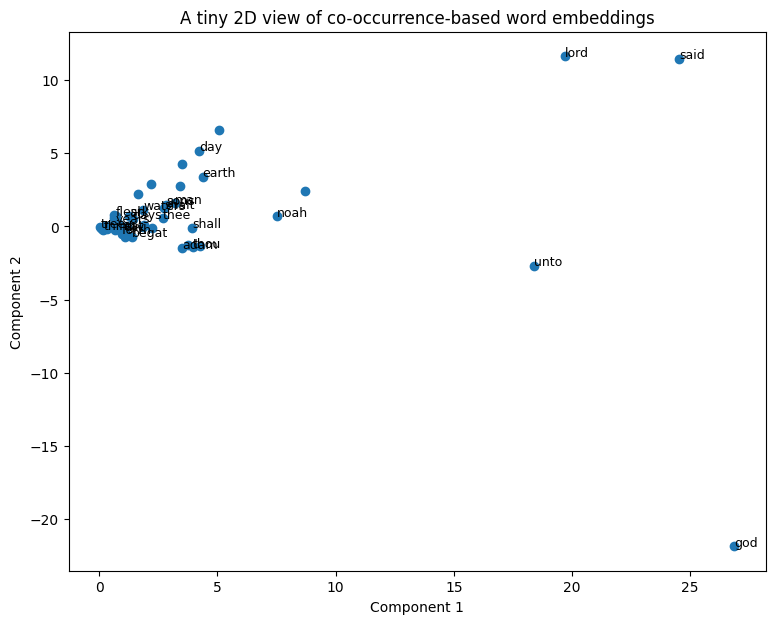

In [67]:
plt.figure(figsize=(9, 7))
plt.scatter(embedding_df["x"], embedding_df["y"])
for _, row in embedding_df.head(25).iterrows():
    plt.text(row["x"], row["y"], row["word"], fontsize=9)
plt.title("A tiny 2D view of co-occurrence-based word embeddings")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## 12. A light introduction to modern transformers

Modern language models use **transformers**, which rely heavily on **self-attention**.

Very roughly:
- each token gets turned into a vector
- the model learns which other tokens to pay attention to
- that weighted context helps predict the next token

Below is a tiny **illustration** of self-attention. The weights are not trained. The point is to see the **mechanism**.


In [68]:
def softmax(x, axis=-1):
    x = x - np.max(x, axis=axis, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=axis, keepdims=True)


def tiny_self_attention_demo(tokens, d_model=8, seed=42):
    rng = np.random.default_rng(seed)

    # Random token embeddings for illustration only
    X = rng.normal(size=(len(tokens), d_model))

    # Learned matrices in a real transformer; random here for a demo
    W_Q = rng.normal(size=(d_model, d_model))
    W_K = rng.normal(size=(d_model, d_model))
    W_V = rng.normal(size=(d_model, d_model))

    Q = X @ W_Q
    K = X @ W_K
    V = X @ W_V

    scores = (Q @ K.T) / math.sqrt(d_model)
    attention_weights = softmax(scores, axis=1)
    context_vectors = attention_weights @ V
    return attention_weights, context_vectors


demo_sentence = "chatbots use context to choose the next token"
demo_tokens = demo_sentence.split()
attention_weights, context_vectors = tiny_self_attention_demo(demo_tokens)

print("Attention matrix shape:", attention_weights.shape)
print("Context vector matrix shape:", context_vectors.shape)

Attention matrix shape: (8, 8)
Context vector matrix shape: (8, 8)


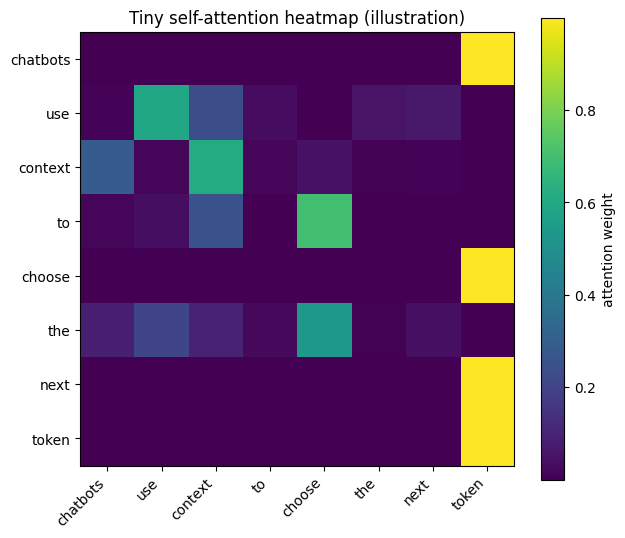

In [34]:
plt.figure(figsize=(7, 6))
plt.imshow(attention_weights)
plt.xticks(range(len(demo_tokens)), demo_tokens, rotation=45, ha="right")
plt.yticks(range(len(demo_tokens)), demo_tokens)
plt.colorbar(label="attention weight")
plt.title("Tiny self-attention heatmap (illustration)")
plt.show()

## 13. Machine translation: two small teaching demos

This final section shows two different ideas:

1. **Style translation**: take a modern prompt and answer in a chosen literary style.
2. **Language translation**: map simple English phrases into a tiny classroom Latin system.

These are deliberately small and transparent. They are not production-quality translators.


In [69]:
def build_chatbot_for_corpus(corpus_name):
    local_corpus = load_corpus(corpus_name)
    return StylizedChatbot(local_corpus)


style_bots = {
    "austen": build_chatbot_for_corpus("austen"),
    "shakespeare": build_chatbot_for_corpus("shakespeare"),
    "bible": build_chatbot_for_corpus("bible"),
}


def style_translate(message, target_style="austen"):
    result = style_bots[target_style].reply(message, temperature=0.8, max_tokens=22)
    return result["response"]


modern_prompt = "Please give me advice about friendship and courage."
for style_name in ["austen", "shakespeare", "bible"]:
    print(style_name.upper())
    print(style_translate(modern_prompt, target_style=style_name))
    print()

AUSTEN
Bingley followed his advice. you know it is above her ancles in dirt and she was very little and was exactly as it

SHAKESPEARE
So by my former lecture and advice Shall you my son. you shall command or confine him where your wisdom should show itself more richer to signify this to me he

BIBLE
1 1 In the beginning God created the heaven and the earth. the earth



In [70]:
MULTIWORD_PHRASES = {
    "thank you": "gratias tibi ago",
    "how are you": "quid agis",
    "my name is": "mihi nomen est",
    "what is your name": "quod nomen tibi est",
    "good morning": "bonum mane",
}

LATIN_DICTIONARY = {
    "hello": "salve",
    "hi": "salve",
    "goodbye": "vale",
    "bye": "vale",
    "thanks": "gratias",
    "yes": "ita",
    "no": "non",
    "friend": "amicus",
    "love": "amor",
    "wisdom": "sapientia",
    "time": "tempus",
    "light": "lux",
    "truth": "veritas",
    "peace": "pax",
    "god": "deus",
    "book": "liber",
    "language": "lingua",
    "word": "verbum",
    "good": "bonus",
    "day": "dies",
    "night": "nox",
    "teacher": "magister",
    "student": "discipulus",
    "chatbot": "machina",
    "name": "nomen",
    "life": "vita",
}


def translate_to_basic_latin(text):
    working = text.lower().strip()

    placeholders = {}
    for i, (phrase, latin) in enumerate(sorted(MULTIWORD_PHRASES.items(), key=lambda x: len(x[0]), reverse=True)):
        placeholder = f"PHRASE{i}TOKEN"
        if phrase in working:
            working = working.replace(phrase, placeholder)
            placeholders[placeholder.lower()] = latin

    tokens = re.findall(r"[a-zA-Z]+(?:'[a-zA-Z]+)?|[.,!?;:]", working)
    translated = []
    for token in tokens:
        lower = token.lower()
        if re.fullmatch(r"[.,!?;:]", token):
            translated.append(token)
        elif lower in placeholders:
            translated.extend(placeholders[lower].split())
        elif lower in LATIN_DICTIONARY:
            translated.append(LATIN_DICTIONARY[lower])
        else:
            translated.append(f"[{token}]")

    return detokenize(translated)


def latin_chatbot(message):
    lowered = message.lower()

    if any(word in lowered for word in ["hello", "hi", "greetings"]):
        return "Salve, amice! Quid vis discere de lingua?"
    if "name" in lowered:
        return "Mihi nomen est Botus Latinus."
    if any(word in lowered for word in ["love", "friendship"]):
        return "Amor et amicitia magna sunt."
    if any(word in lowered for word in ["time", "life"]):
        return "Tempus fugit, sed verba manent."
    if any(word in lowered for word in ["thank", "thanks"]):
        return "Libenter!"
    if any(word in lowered for word in ["bye", "goodbye", "farewell"]):
        return "Vale et disce feliciter!"

    translated_message = translate_to_basic_latin(message)
    return f"Dicere possum: {translated_message}"


latin_examples = [
    "hello friend",
    "thank you teacher",
    "what is your name?",
    "love and wisdom",
]

for example in latin_examples:
    print("English:", example)
    print("Latin  :", translate_to_basic_latin(example))
    print()

print("Latin chatbot demo:")
print("USER:", "Hello, what is your name?")
print("BOT :", latin_chatbot("Hello, what is your name?"))

English: hello friend
Latin  : salve amicus

English: thank you teacher
Latin  : [PHRASE] [TOKEN] magister

English: what is your name?
Latin  : [PHRASE] [TOKEN]

English: love and wisdom
Latin  : amor [and] sapientia

Latin chatbot demo:
USER: Hello, what is your name?
BOT : Salve, amice! Quid vis discere de lingua?


## 14. What we learned

We started with a public-domain text and built a gentle NLP pipeline:
- text loading and cleaning
- tokenization
- stop words
- Zipf's law
- POS tagging
- n-grams and skip-grams
- probabilistic next-token generation
- a stylized chatbot
- a tiny embedding demo
- a tiny transformer self-attention demo
- simple translation ideas

That progression mirrors a big idea in NLP:

**raw text -> tokens -> statistics -> structure -> generation -> vector representations -> modern neural models**

